# Cell Phone Price Range Prediction

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Load the Dataset

In [2]:
df=pd.read_csv('datasets_11167_15520_train.csv')

In [3]:
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


# Explore Data Analysis(EDA)

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df.describe

<bound method NDFrame.describe of       battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0               842     0          2.2         0   1       0           7   
1              1021     1          0.5         1   0       1          53   
2               563     1          0.5         1   2       1          41   
3               615     1          2.5         0   0       0          10   
4              1821     1          1.2         0  13       1          44   
...             ...   ...          ...       ...  ..     ...         ...   
1995            794     1          0.5         1   0       1           2   
1996           1965     1          2.6         1   0       0          39   
1997           1911     0          0.9         1   1       1          36   
1998           1512     0          0.9         0   4       1          46   
1999            510     1          2.0         1   5       1          45   

      m_dep  mobile_wt  n_cores  ...  px_height  px_w

# Data Cleaning


In [7]:
df.isnull()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
print(df.dtypes)

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


In [9]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Observation

Data preprocessing is an important step that prepares the dataset for machine learning. In this project, missing values were checked, the target variable and features were separated, and feature scaling was applied using StandardScaler. Scaling ensures that all numerical features are on a similar scale, which helps distance-based models such as KNN and SVM perform more effectively. There are no null values in the dataset.

# Data Visualization

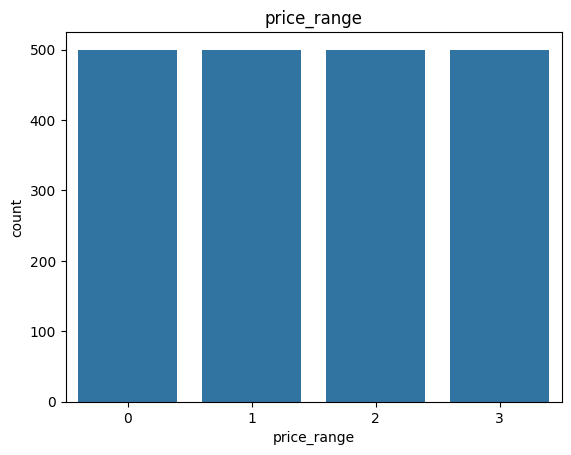

In [11]:
sns.countplot(x="price_range",data=df)
plt.title("price_range")
plt.show()

 It shows how many phones are in each price category(0,1,2&3)

# HEAT MAP

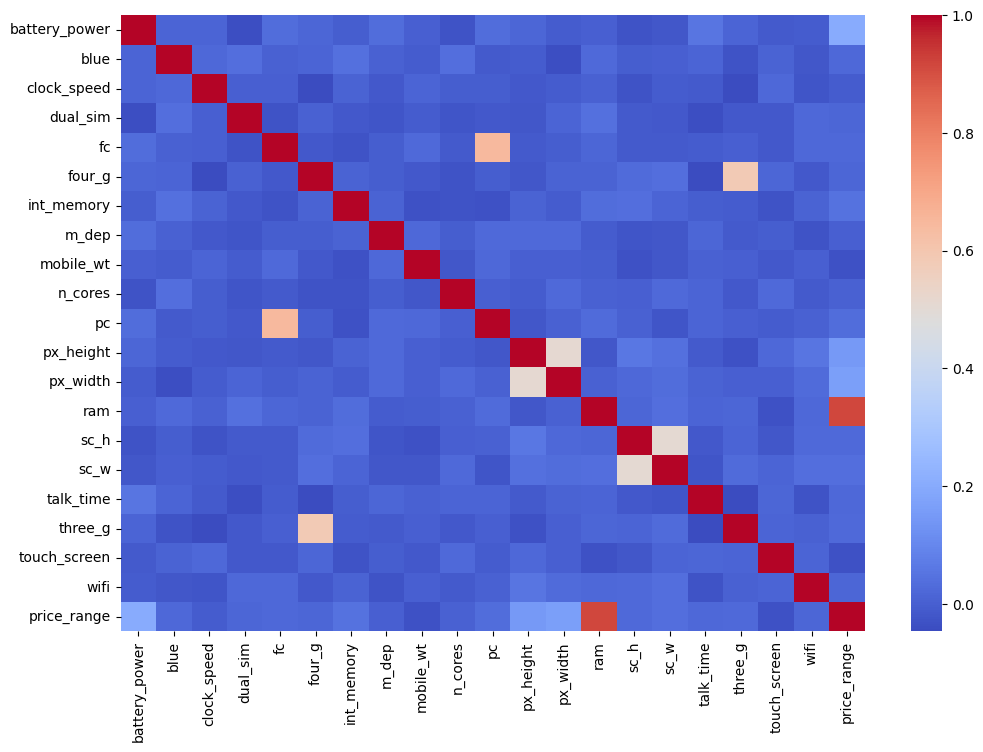

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

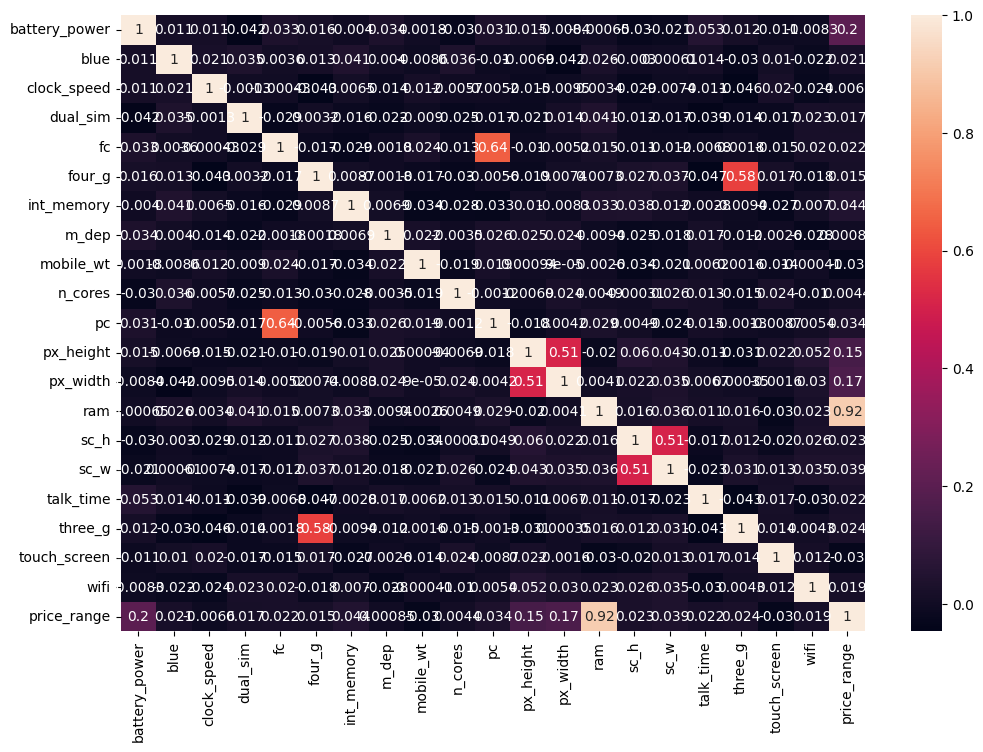

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [14]:
# for neat and clear graph

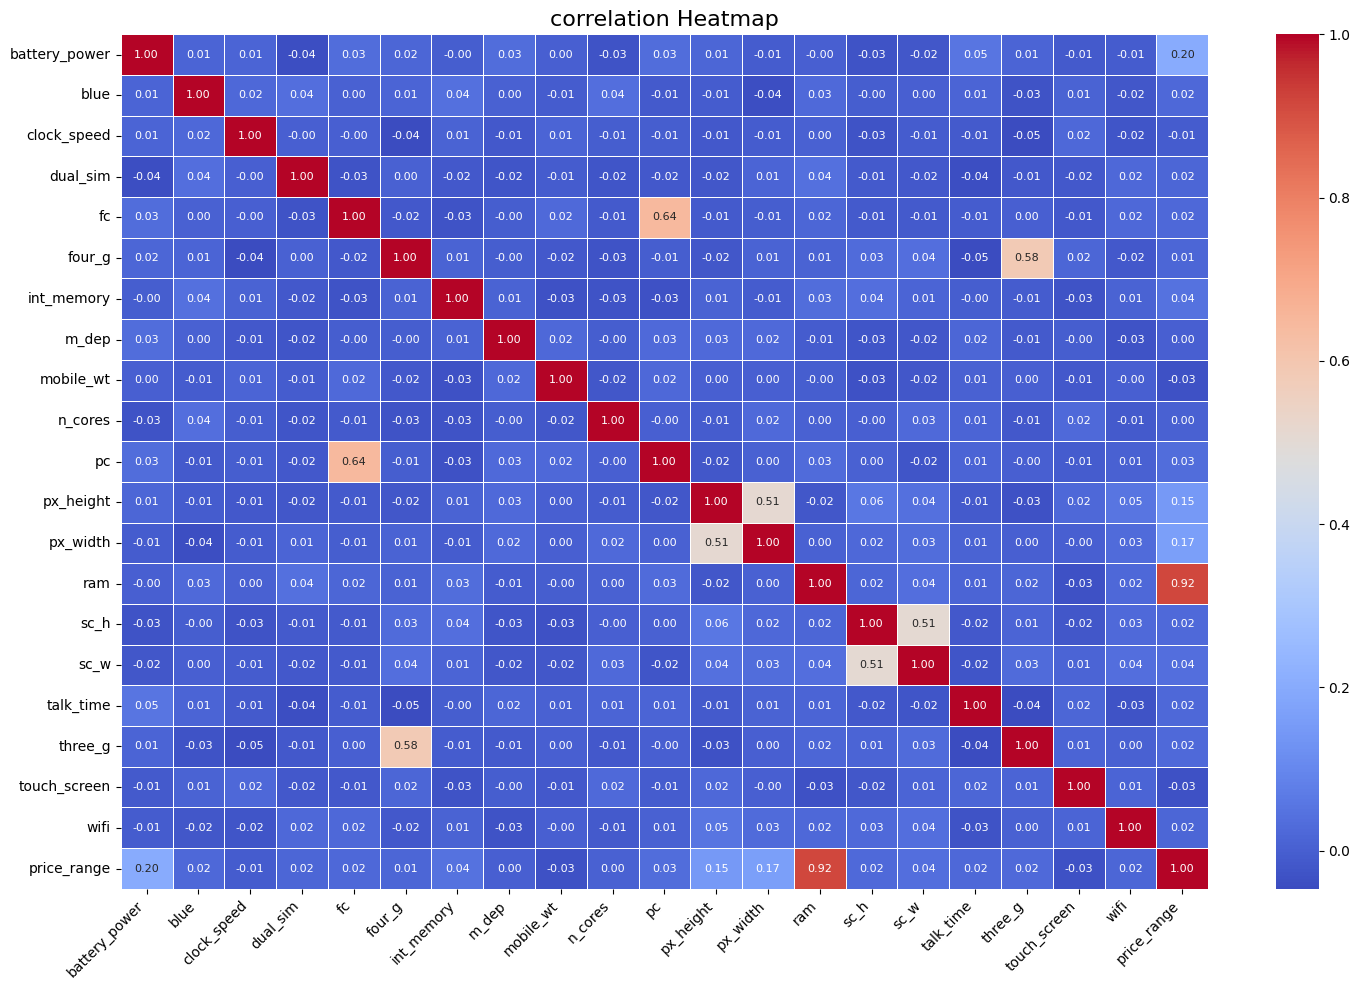

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidth=0.5,annot_kws={"size":8})
plt.title("correlation Heatmap",fontsize=16)
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# BOX PLOT
A box plot is used to summarize the distribution of numerical data and identify potential outliers. It displays the median, quartiles, and spread of the data, making it useful for understanding data variability.

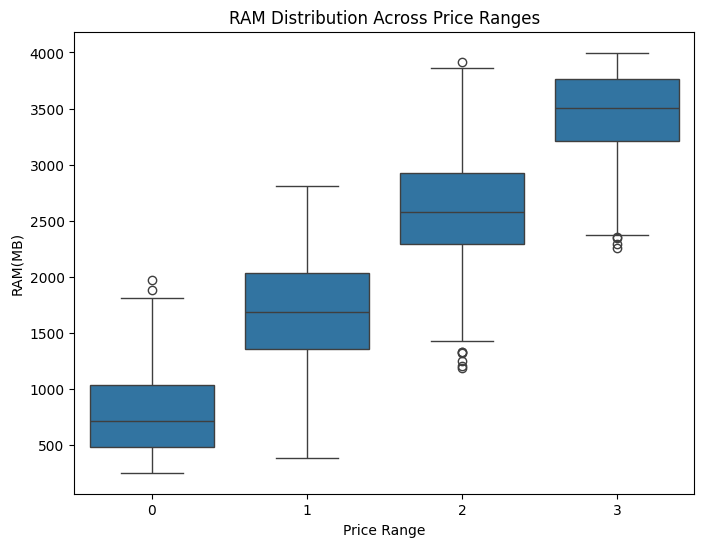

In [16]:
plt.figure(figsize=(8,6))
sns. boxplot(x='price_range',y='ram',data=df)
plt.title("RAM Distribution Across Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("RAM(MB)")
plt.show()

# Observation
The box plot indicates a few potential outliers in the RAM feature across different price ranges.
These values represent realistic variations in mobile specifications rather than data errors,so they were retained for model training

# HISTOGRAM
A histogram is used to visualize the distribution of numerical features by showing how frequently different values occur. It helps identify the shape of the data, such as whether it is normally distributed, skewed, or uniformly distributed.

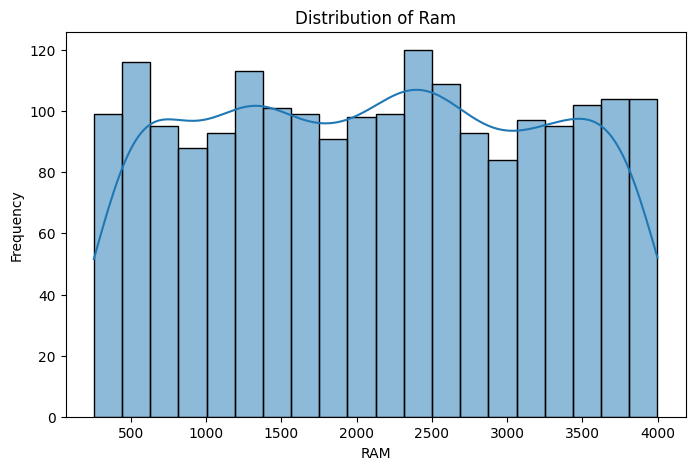

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['ram'],bins=20,kde=True)
plt.title("Distribution of Ram")
plt.xlabel("RAM")
plt.ylabel("Frequency")
plt.show()

# Observation:
The histogram shows the distribution of numerical features such as RAM, battery power, and internal memory. Most features are well distributed without extreme skewness, indicating that the dataset is suitable for machine learning model training.

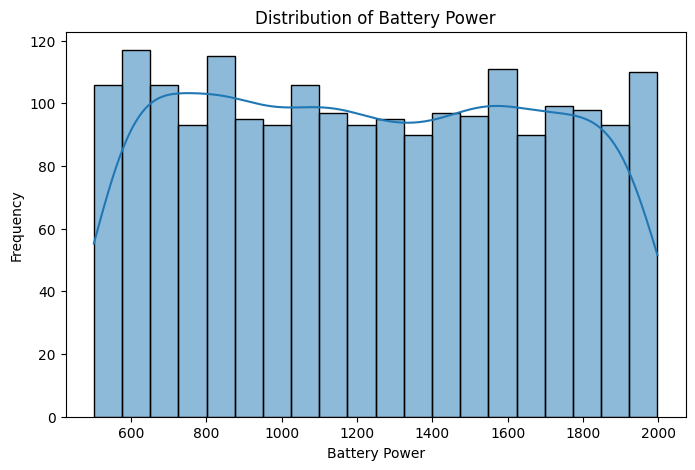

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['battery_power'],bins=20,kde=True)
plt.title("Distribution of Battery Power")
plt.xlabel("Battery Power")
plt.ylabel("Frequency")
plt.show()

Observation:

Battery power is fairly evenly distributed across the dataset.
This suggests that the dataset includes phones with a variety of battery capacities, which can contribute to price prediction.

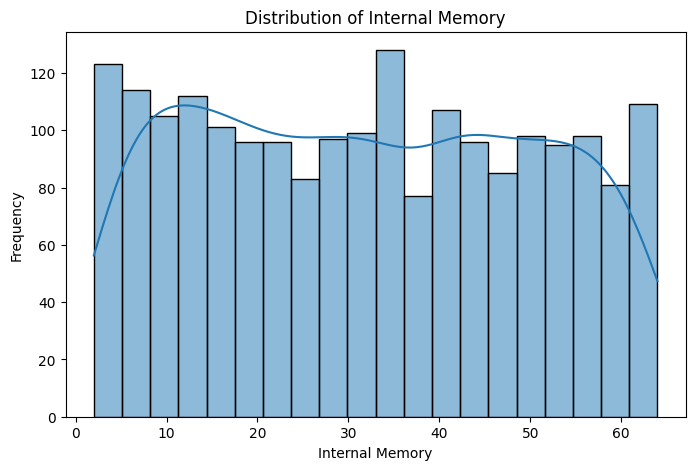

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['int_memory'],bins=20,kde=True)
plt.title("Distribution of Internal Memory")
plt.xlabel("Internal Memory")
plt.ylabel("Frequency")
plt.show()

Observation:

Internal memory values are spread across different storage capacities, showing a diverse set of mobile phones.
This feature is likely to influence the predicted price range.

# Create X and Y

In [20]:
x=df.drop('price_range',axis=1)
y=df['price_range']

## Observation

The dataset was divided into independent variables (X) and the dependent variable (Y). The `price_range` column was selected as the target variable (Y), while all remaining mobile specifications were used as input features (X) to train the machine learning models.

# TrainTestSplit

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## Observation

The dataset was divided into training and testing sets using an 80:20 ratio. The training set (80%) was used to train the machine learning models, while the testing set (20%) was used to evaluate their performance. The `stratify=y` parameter was used to maintain an equal distribution of all price range classes in both training and testing datasets, resulting in a fair and reliable evaluation.

# Feature Scaling

In [22]:
from sklearn. preprocessing import StandardScaler
Scaler=StandardScaler()
x_train=Scaler.fit_transform(x_train)
x_test=Scaler.transform(x_test)

## Observation

Feature Scaling was performed using StandardScaler to standardize all numerical features. This transforms the data so that each feature has a mean of 0 and a standard deviation of 1. Scaling improves the performance of algorithms such as KNN, SVM, and Logistic Regression by preventing features with larger values from dominating the learning process.

#  First Model- Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
lr_pred=lr_model.predict(x_test)
print(lr_pred)

[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3 1 0 3 2 2 1 1 0 2 1 1 2 0 2 2 3 0
 3 1 0 2 0 0 2 3 0 3 3 2 1 0 3 0 2 0 3 3 0 2 1 1 2 3 1 0 1 0 1 3 3 3 2 1 1
 2 0 3 3 1 3 3 2 2 0 0 1 0 0 0 0 0 2 2 3 0 3 0 0 2 2 3 1 1 0 3 3 1 2 1 1 0
 2 3 1 3 2 2 2 2 2 2 0 3 0 3 3 2 0 2 3 3 0 0 1 3 1 2 3 2 3 3 3 2 1 3 2 1 1
 0 1 3 0 1 1 3 3 3 2 0 2 2 0 0 3 1 1 3 2 3 0 1 1 1 3 2 1 1 3 0 3 2 2 2 3 0
 2 0 1 1 1 0 2 1 2 3 0 2 3 1 1 1 2 1 2 0 0 3 1 1 2 1 3 2 0 0 3 1 2 3 3 0 3
 3 2 2 1 1 2 1 1 0 2 0 0 0 0 0 2 2 2 2 3 0 1 3 2 2 3 3 2 1 0 3 3 1 3 2 2 2
 2 2 2 2 1 0 0 3 1 2 3 3 0 0 0 1 3 2 2 3 1 3 2 2 1 1 0 1 1 1 3 1 0 3 1 1 1
 0 1 1 1 1 3 0 3 2 3 1 2 1 2 0 0 2 3 3 2 3 1 0 2 0 2 3 3 0 0 3 2 0 1 1 0 0
 0 0 0 3 1 3 0 1 2 3 2 3 0 2 1 2 3 3 0 2 3 1 0 0 1 2 3 3 1 1 0 3 3 3 1 2 1
 1 0 0 3 1 0 0 0 3 1 1 2 0 3 0 3 2 3 2 2 0 1 1 1 0 1 2 1 2 2]


# Accuracy of Logistic Regression

In [25]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,lr_pred)
print("LogisticRegressionAccuracy:",accuracy,lr_model)
print(confusion_matrix(y_test,lr_pred))
print(classification_report(y_test, lr_pred))

LogisticRegressionAccuracy: 0.965 LogisticRegression()
[[98  2  0  0]
 [ 1 96  3  0]
 [ 0  2 94  4]
 [ 0  0  2 98]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



# Observation:

The Logistic Regression model achieved an accuracy of 96.5%, indicating excellent performance in predicting the mobile phone price range.
The confusion matrix shows that most samples were classified correctly,and the classification report demonstrates high precision, recall,and F1-score
across all four price categories.

# Decision Tree

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
print(dt_pred)

[3 2 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 2 1 0 3 2 2 2 1 0 2 1 1 2 0 2 2 3 0
 3 1 0 2 0 0 2 3 0 3 3 3 2 0 3 0 2 0 3 3 0 2 1 1 2 3 1 1 0 0 2 3 3 3 1 1 2
 2 0 2 3 1 2 3 2 2 0 0 1 0 0 0 1 0 2 2 3 0 3 1 0 2 2 3 1 1 1 3 3 2 2 1 1 0
 2 3 1 3 2 2 2 2 2 3 0 3 0 2 3 2 1 3 3 3 0 0 2 2 1 1 3 1 3 3 3 2 1 3 2 1 1
 0 0 3 0 0 0 3 3 3 3 1 1 1 0 0 3 1 1 2 2 3 0 1 1 1 3 3 1 0 3 0 3 2 2 2 3 0
 1 0 1 1 1 0 2 1 2 3 0 2 3 1 1 1 2 0 2 0 0 3 1 1 1 0 2 2 0 0 3 1 2 3 3 0 3
 2 2 2 1 2 2 0 1 0 2 0 0 0 0 0 2 2 3 2 3 0 1 3 2 2 3 3 2 2 0 3 3 1 3 2 2 1
 2 2 2 2 1 0 0 3 0 2 3 2 0 0 0 1 3 2 2 3 1 3 2 2 2 1 0 1 1 1 3 1 0 3 1 1 1
 0 0 1 1 0 3 0 2 2 3 0 2 0 2 0 0 1 2 3 2 3 1 0 2 0 2 3 3 0 0 3 2 0 1 0 0 0
 0 0 0 3 1 3 0 1 2 2 2 3 1 2 1 2 3 2 0 2 3 1 1 0 1 3 2 3 1 1 0 3 3 3 1 2 2
 1 0 0 2 1 0 0 0 3 1 1 2 0 3 0 3 1 3 2 2 0 1 2 1 0 1 2 1 2 1]


# Accuracy of DecisionTree

In [27]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,dt_pred)
print("DecisionTreeAccuracy:",accuracy,dt_model)
print(confusion_matrix(y_test,dt_pred))
print(classification_report(y_test,dt_pred))

DecisionTreeAccuracy: 0.8425 DecisionTreeClassifier()
[[92  8  0  0]
 [13 75 12  0]
 [ 0 10 83  7]
 [ 0  0 13 87]]
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       100
           1       0.81      0.75      0.78       100
           2       0.77      0.83      0.80       100
           3       0.93      0.87      0.90       100

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



# Observation:

The Decision Tree Classifier achieved an accuracy of 85.25%. While it performed reasonably well,it misclassified more samples than LogisticRegression,
particularly between adjacent price categories.
This indicates that the Decision Tree was less effective for this dataset.

# RandomForest

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)
print(rf_pred)

[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3 1 0 3 2 2 1 1 0 2 1 1 2 0 2 2 3 0
 3 1 0 2 0 0 2 3 0 3 3 2 2 0 3 0 2 0 3 3 0 2 1 1 2 3 1 0 0 0 1 3 3 3 2 1 1
 2 1 3 3 1 3 3 2 2 0 0 1 0 0 0 1 0 2 2 2 0 3 0 0 2 2 3 1 1 0 3 3 2 2 1 1 0
 2 3 1 3 2 2 3 2 2 3 0 3 0 2 3 2 1 2 3 3 0 0 2 3 1 1 3 2 3 3 3 2 1 3 2 1 1
 0 1 3 0 1 1 3 3 3 2 0 2 1 0 0 3 1 1 2 1 3 0 1 1 1 3 2 1 0 3 0 3 2 2 2 3 0
 2 0 1 1 1 0 2 1 2 3 0 2 3 1 1 1 2 0 3 0 0 3 1 1 1 0 2 2 0 0 3 1 2 3 3 0 3
 2 1 2 1 1 2 1 1 0 1 0 0 0 0 0 2 1 3 2 3 0 1 3 1 2 3 3 2 1 0 3 3 1 3 2 1 1
 2 2 2 3 1 0 0 3 1 2 3 2 0 0 0 1 3 2 2 3 1 3 2 2 2 1 0 1 1 2 3 1 0 3 1 1 1
 0 1 1 2 1 3 0 2 2 3 1 2 1 1 0 0 2 3 3 2 3 1 0 2 0 3 3 3 0 0 3 1 0 2 0 0 0
 0 0 0 3 1 3 0 1 2 3 2 3 0 2 1 2 3 3 0 2 3 1 0 0 1 2 2 3 1 1 0 3 3 3 2 2 1
 1 0 0 3 1 0 0 0 3 1 2 1 0 3 0 3 2 3 2 2 0 2 1 1 0 1 2 1 1 2]


# Accuracy of RandomForest

In [29]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_test,rf_pred)
print("RandomForestAccuracy:",accuracy,rf_model)
print(confusion_matrix(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

RandomForestAccuracy: 0.88 RandomForestClassifier(random_state=42)
[[96  4  0  0]
 [ 5 84 11  0]
 [ 0 14 79  7]
 [ 0  0  7 93]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       100
           1       0.82      0.84      0.83       100
           2       0.81      0.79      0.80       100
           3       0.93      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



# Observation:
The Random Forest Classifier achieved an accuracy of 88.0%, outperforming the Decision Tree but not Logistic Regression. Although Random Forest handled the classification reasonably well, Logistic Regression provided the highest overall accuracy for this dataset.

# KNN

In [30]:
from sklearn. neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=9)
knn_model.fit(x_train,y_train)
knn_pred=knn_model.predict(x_test)
print(knn_pred)

[3 2 0 1 1 2 1 1 0 1 3 0 0 1 3 3 1 0 1 2 1 0 3 3 2 1 1 0 1 2 1 1 0 2 0 3 1
 2 2 0 2 0 1 2 3 0 3 2 2 2 0 2 0 2 1 1 2 1 3 2 2 1 3 2 0 1 0 1 1 3 3 1 0 1
 2 1 2 1 0 2 3 1 2 0 0 0 0 1 0 1 0 1 3 3 0 1 2 1 3 2 3 2 2 0 3 3 0 2 1 1 0
 2 3 3 3 2 1 3 1 1 3 0 3 1 1 3 2 0 3 3 1 1 0 2 2 2 1 3 0 3 3 3 2 0 3 2 2 1
 0 1 3 0 1 0 3 3 1 2 0 3 1 0 0 2 2 1 3 2 2 0 0 2 0 3 2 0 0 3 0 2 1 1 1 3 0
 1 0 1 0 0 0 3 1 2 3 0 1 3 1 1 2 1 3 2 0 0 2 1 0 3 1 3 2 0 0 1 2 1 2 3 1 3
 2 1 1 1 1 2 2 0 0 1 1 0 0 1 0 2 2 3 2 2 0 0 3 1 3 3 3 2 2 0 2 3 1 2 2 2 0
 2 3 1 2 2 1 0 3 1 3 3 3 0 0 0 2 3 2 1 3 2 3 2 2 1 1 0 1 0 1 3 1 0 3 1 1 1
 0 1 1 2 1 2 0 3 3 3 1 1 1 1 0 0 2 3 2 3 3 2 0 2 2 2 3 3 0 0 2 1 1 0 2 2 0
 0 1 1 3 0 1 0 2 1 3 3 3 0 2 1 2 3 3 1 3 1 1 0 0 1 2 3 3 0 2 1 3 2 2 2 2 0
 0 0 0 3 1 0 1 0 2 1 2 2 1 2 0 2 1 2 3 2 0 0 1 1 0 1 1 1 1 0]


# Accuracy Of KNN

In [31]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("KNN Accuracy:",accuracy_score(y_test,knn_pred))
print(confusion_matrix(y_test,knn_pred))
print(classification_report(y_test,knn_pred))

KNN Accuracy: 0.5625
[[71 26  3  0]
 [25 46 27  2]
 [ 3 33 44 20]
 [ 0 10 26 64]]
              precision    recall  f1-score   support

           0       0.72      0.71      0.71       100
           1       0.40      0.46      0.43       100
           2       0.44      0.44      0.44       100
           3       0.74      0.64      0.69       100

    accuracy                           0.56       400
   macro avg       0.58      0.56      0.57       400
weighted avg       0.58      0.56      0.57       400



In [32]:
print(df.shape)
print(df['price_range'].value_counts())

(2000, 21)
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [33]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 20)
(400, 20)
(1600,)
(400,)


# Observation:
K-Nearest Neighbors (KNN) achieved an accuracy of 56.25%, which was lower than the other classification models. Despite testing multiple values of k, the performance remained lower, indicating that KNN was less suitable for this dataset compared to Logistic Regression, Random Forest, and Decision Tree.

# Support Vector Machine

In [34]:
from sklearn.svm import SVC
svm_model=SVC(kernel='linear',random_state=42)
svm_model.fit(x_train,y_train)
svm_pred=svm_model.predict(x_test)
print(svm_pred)

[3 1 0 2 3 2 0 0 1 0 3 0 0 1 3 3 2 0 1 3 1 0 3 2 2 1 1 0 2 1 1 2 0 2 2 3 0
 3 1 0 2 0 0 2 3 0 3 3 2 1 0 3 0 2 0 3 3 0 2 1 1 2 3 1 0 1 0 1 3 3 3 2 1 1
 2 0 3 3 2 3 3 2 2 0 0 1 0 0 0 0 0 2 2 3 0 3 0 0 2 2 3 1 1 0 3 3 1 2 1 1 0
 2 3 1 3 2 2 2 2 2 2 0 3 0 3 3 2 0 2 3 3 0 0 1 3 1 2 3 1 3 3 3 2 1 3 2 1 1
 0 1 3 0 1 1 3 3 3 3 0 2 2 0 0 3 1 1 3 2 3 0 1 1 1 3 2 1 1 3 0 3 2 2 2 3 0
 2 0 1 1 1 0 2 1 2 3 0 2 3 1 1 1 2 1 2 0 0 3 1 1 2 1 3 2 0 0 3 1 2 3 3 0 3
 3 2 2 1 2 2 1 1 0 2 0 0 1 0 0 2 2 2 2 3 0 1 3 2 2 3 3 2 1 0 3 3 1 3 2 2 2
 2 2 2 2 1 0 0 3 1 2 3 3 0 0 0 1 3 2 2 3 1 3 2 2 1 1 0 1 1 1 3 1 0 3 1 1 1
 1 1 1 1 1 3 0 3 2 3 1 2 1 2 0 0 2 3 3 2 3 1 0 2 0 2 3 3 0 0 3 2 0 1 1 0 0
 0 0 0 3 1 3 0 2 2 3 2 3 0 2 1 2 3 3 0 2 3 1 0 0 1 2 3 3 1 1 0 3 3 3 1 2 1
 1 0 0 3 1 0 0 0 3 1 1 2 0 3 0 3 2 3 2 2 0 1 1 1 0 1 2 1 2 2]


# Accuracy of Support Vector Machine

In [35]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("SVC Accuracy:",accuracy_score(y_test,svm_pred))
print(confusion_matrix(y_test,svm_pred))
print(classification_report(y_test,svm_pred))

SVC Accuracy: 0.9625
[[96  4  0  0]
 [ 1 95  4  0]
 [ 0  1 95  4]
 [ 0  0  1 99]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       100
           1       0.95      0.95      0.95       100
           2       0.95      0.95      0.95       100
           3       0.96      0.99      0.98       100

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



# Observation:

The Support Vector Machine (SVM) achieved an accuracy of 96.25%, demonstrating excellent performance in classifying mobile phones into their correct price ranges. The confusion matrix shows that the majority of samples were classified correctly, while the classification report indicates high precision, recall, and F1-score across all four classes.
This makes SVM one of the best-performing models for this dataset.

# Hyperparameter Tuning using GridSearchCV
GridSearchCV is used to find the best combination of hyperparameters for a machine learning model. Instead of manually testing different values, it automatically evaluates multiple combinations using cross-validation and selects the one that gives the highest accuracy. This helps improve the model's performance and reduces the risk of overfitting.

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.8706249999999999


# Observation

GridSearchCV identified the optimal hyperparameters for the Random Forest model as 200 decision trees (n_estimators=200), a maximum tree depth of 20 (max_depth=20), and a minimum of 5 samples required to split an internal node (min_samples_split=5). Using these parameters, the model achieved a cross-validation accuracy of 87.06%, indicating that these settings provide a good balance between model performance and generalization.

Hyperparameter tuning improved the selection of Random Forest parameters by automatically evaluating multiple combinations through cross-validation. This process helps build a more reliable model and reduces the chances of overfitting compared to using only default parameter values.

# Feature Importance
Feature importance is used to identify which features have the greatest influence on the model's predictions.
It helps us understand which mobile specifications contribute the most to determining the price range.
By analyzing feature importance, we can interpret the model better, select the most relevant features, and reduce unnecessary variables.

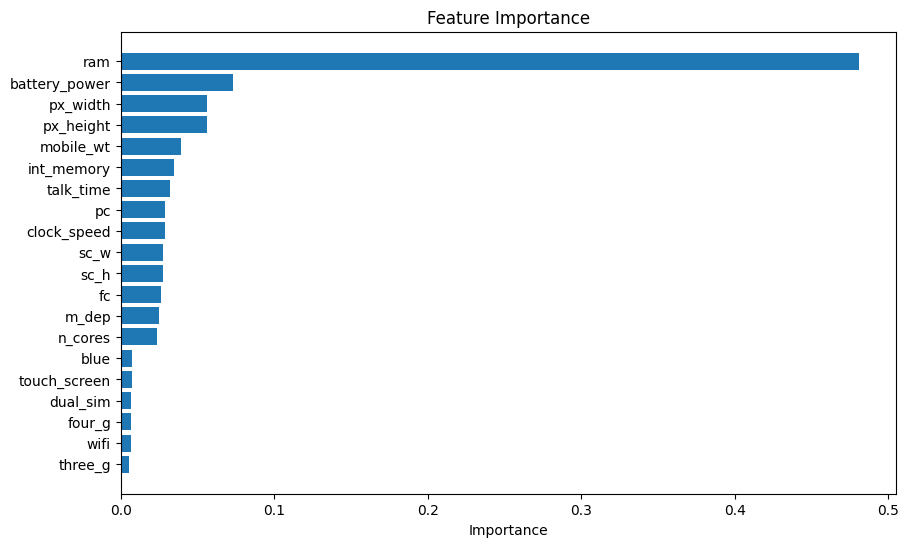

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

# Observation

The feature importance analysis shows that RAM is the most influential feature in predicting the mobile phone price range.
Battery power, pixel height, pixel width, mobile weight, and internal memory also have a significant impact on the prediction. On the other hand, features such as Wi-Fi, 3G, 4G, dual SIM, and touch screen have relatively lower importance, 
indicating that they contribute less to the model's predictions.

# Model Comparison
Model comparison is performed to evaluate the performance of different machine learning algorithms on the same dataset.
It helps identify the model that provides the highest accuracy and best overall performance for predicting the mobile phone price range.

| Model                        |   Accuracy |
| ---------------------------- | ---------: |
| Logistic Regression          | **96.50%** |
| Decision Tree                |     85.25% |
| Random Forest                |     88.00% |
| K-Nearest Neighbors (KNN)    |     56.25% |
| Support Vector Machine (SVM) |     96.25% |


# Observation

Among all the machine learning models, Logistic Regression achieved the highest accuracy of 96.50%, followed closely by Support Vector Machine (96.25%).
Decision Tree and Random Forest provided satisfactory performance, whereas KNN achieved the lowest accuracy. 
Therefore, Logistic Regression was selected as the best-performing model for this dataset.

# Business Impact
Business impact explains how the developed machine learning model can be applied in real-world scenarios to solve practical problems and support decision-making.

This model can assist smartphone manufacturers, retailers, and e-commerce platforms in automatically classifying mobile phones into different price ranges based on their specifications. It can support pricing strategies, inventory management, and product recommendations. Customers can also benefit by comparing devices with similar features and price categories

# Future Scope
Future scope highlights possible improvements that can enhance the model's performance and expand its real-world applications.

Future Scope:

Improve the model further using advanced hyperparameter tuning techniques.

Train the model on larger and more diverse datasets.

Explore advanced algorithms such as XGBoost, LightGBM, and CatBoost.

Deploy the model as a web application using Flask or Streamlit.

Integrate the model into e-commerce platforms for automatic mobile price range prediction.

# Conclusion

This project successfully developed a machine learning-based model to classify mobile phones into different price ranges based on their specifications. A systematic workflow was followed, including data exploration, exploratory data analysis (EDA), data preprocessing, feature scaling, model training, hyperparameter tuning, and performance evaluation. Five classification algorithms—Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM)—were implemented and compared using accuracy, confusion matrix, and classification report.

Among all the models, Logistic Regression achieved the highest accuracy of 96.50%, followed closely by Support Vector Machine (96.25%), demonstrating excellent predictive performance. Feature importance analysis also showed that RAM, battery power, and display-related features play a significant role in determining the price range of mobile phones.

The results demonstrate that machine learning techniques can effectively classify mobile phones into different price categories with high accuracy. This project provides valuable insights into the factors influencing smartphone pricing and has practical applications for manufacturers, retailers, and e-commerce platforms. Overall, the project successfully achieved its objective and serves as a strong foundation for developing intelligent pricing and product recommendation systems in real-world scenarios.


## References

• Scikit-learn Documentation

• Pandas Documentation

• NumPy Documentation

• Matplotlib Documentation

• Kaggle Mobile Price Classification Dataset